In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
data = yf.download("AAPL", start="2023-01-01", end="2024-01-01")
data = data[['Close']]
data.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2023-01-03,123.470604
2023-01-04,124.744118
2023-01-05,123.421257
2023-01-06,127.962395
2023-01-09,128.485657


In [3]:
data['SMA20'] = data['Close'].rolling(window=20).mean()
data['SMA50'] = data['Close'].rolling(window=50).mean()

# Generate signals
data['Signal'] = 0
data.loc[data['SMA20'] > data['SMA50'], 'Signal'] = 1
data.loc[data['SMA20'] < data['SMA50'], 'Signal'] = -1

data[['Close', 'SMA20', 'SMA50', 'Signal']].dropna().tail()

Price,Close,SMA20,SMA50,Signal
Ticker,AAPL,,,
Date,,,,
2023-12-22,192.192535,192.260548,183.959353,1
2023-12-26,191.646561,192.422364,184.245961,1
2023-12-27,191.745819,192.558865,184.537132,1
2023-12-28,192.172714,192.767836,184.867971,1
2023-12-29,191.130325,192.895897,185.203938,1


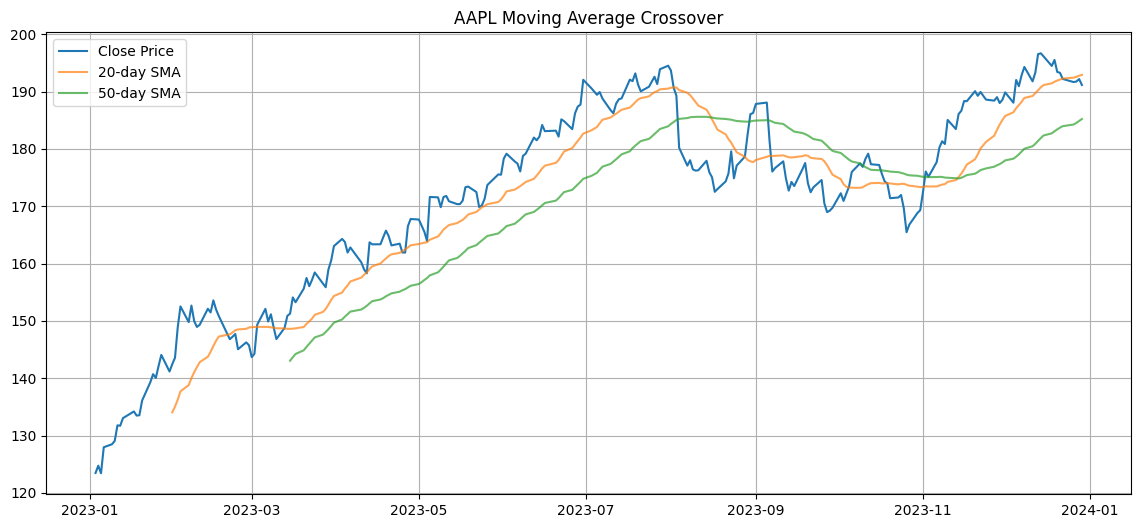

In [4]:
plt.figure(figsize=(14,6))
plt.plot(data['Close'], label='Close Price')
plt.plot(data['SMA20'], label='20-day SMA', alpha=0.7)
plt.plot(data['SMA50'], label='50-day SMA', alpha=0.7)
plt.legend()
plt.title('AAPL Moving Average Crossover')
plt.grid(True)
plt.show()